# 02 – Multi-Layer Perceptron (MLP)

Este notebook implementa e avalia modelos MLP para classificação de borboletas (75 classes).

## Experiências realizadas
| Experimento | Arquitectura | Loss | Optimizador |
|-------------|-------------|------|-------------|
| MLP-A-CE-RMS | Pequena (2 hidden) | CrossEntropy | RMSprop |
| MLP-A-CE-ADAM | Pequena (2 hidden) | CrossEntropy | ADAM |
| MLP-A-MM-RMS | Pequena (2 hidden) | MultiMargin | RMSprop |
| MLP-A-MM-ADAM | Pequena (2 hidden) | MultiMargin | ADAM |
| MLP-B-CE-RMS | Grande (4 hidden) | CrossEntropy | RMSprop |
| MLP-B-CE-ADAM | Grande (4 hidden) | CrossEntropy | ADAM |
| MLP-B-MM-RMS | Grande (4 hidden) | MultiMargin | RMSprop |
| MLP-B-MM-ADAM | Grande (4 hidden) | MultiMargin | ADAM |

## 1. Importações e configuração

In [1]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
import json
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import StepLR

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, top_k_accuracy_score
)

import kagglehub

# Reproducibilidade
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: mps


/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Pipeline de dados

> **Nota sobre `IMAGE_SIZE`:** O notebook de exploração de dados (`01_data_exploration.ipynb`)
> confirmou que todas as imagens têm resolução original de **224×224 px**. Aqui usamos
> **`IMAGE_SIZE=64`** (redução deliberada) porque o MLP recebe a imagem como um vector
> flat de pixels: 224×224×3 = 150 528 valores vs 64×64×3 = 12 288 valores.
> Trabalhar com 224 tornaria o treino proibitivamente lento e o modelo extremamente grande
> sem ganhos significativos, pois o MLP não explora estrutura espacial.
> Esta redução **não introduz viés ao comparar MLP vs CNN/ResNet** porque cada modelo
> usa o `IMAGE_SIZE` que maximiza a sua eficiência (CNNs e ResNet usarão resoluções maiores).

### Justificação das métricas
- **Accuracy**: métrica primária – o dataset está apenas *ligeiramente* desbalanceado (min 57, max 105 imagens/classe), pelo que accuracy é uma proxy razoável para o desempenho global.
- **Macro F1-Score**: média não ponderada por classe – penaliza igualmente erros em classes pequenas, complementando a accuracy.
- **Top-5 Accuracy**: útil em classificação fine-grained com 75 classes visualmente semelhantes.
- **Confusion matrix**: inspecção qualitativa de padrões de confusão.

### Data augmentation
Alinhado com `01_data_exploration.ipynb`:
- `RandomHorizontalFlip(p=0.5)` – borboletas têm simetria bilateral
- `RandomRotation(10°)` – robustez a pequenas rotações
- `ColorJitter(0.2, 0.2, 0.2, hue=0.05)` – variação de cor/brilho
- **Sem** `RandomCrop` (ao contrário de CNNs) – o MLP precisa de dimensão fixa e o crop daria um input com dimensão variável se não houvesse padding controlado.

In [2]:
# ── Hiperparâmetros globais ──────────────────────────────────────────────────
BATCH_SIZE  = 64
IMAGE_SIZE  = 64          # imagens redimensionadas para 64×64
FLAT_SIZE   = 3 * IMAGE_SIZE * IMAGE_SIZE   # 3×64×64 = 12 288
NUM_CLASSES = 75
NUM_EPOCHS  = 30
LR          = 1e-3
VAL_SPLIT   = 0.2         # 20 % de validação

# ── Download do dataset ──────────────────────────────────────────────────────
path = kagglehub.competition_download('aca-butterflies')
img_dir   = os.path.join(path, 'train')
train_csv = os.path.join(path, 'train.csv')
print(f'Dataset em: {path}')

df = pd.read_csv(train_csv)
print(f'Total de amostras: {len(df)}  |  Classes: {df["label"].nunique()}')

Dataset em: /Users/matildecarvalho/.cache/kagglehub/competitions/aca-butterflies
Total de amostras: 5199  |  Classes: 75


In [3]:
# ── Mapeamento classe → índice (consistente com 01_data_exploration) ─────────
classes = sorted(df['label'].unique())
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {v: k for k, v in class_to_idx.items()}
print(f'Número de classes: {len(classes)}')

Número de classes: 75


In [4]:
class ButterflyDataset(data.Dataset):
    """Dataset de borboletas para o projeto ACA."""

    def __init__(self, df, img_dir, class_to_idx, transform=None):
        self.img_labels  = df.reset_index(drop=True)
        self.img_dir     = img_dir
        self.class_to_idx = class_to_idx
        self.transform   = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        row = self.img_labels.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image    = Image.open(img_path).convert('RGB')
        label    = torch.tensor(self.class_to_idx[row['label']], dtype=torch.long)
        if self.transform:
            image = self.transform(image)
        return image, label

In [ ]:
# ── Transforms ──────────────────────────────────────────────────────────────
# Augmentation do treino alinhado com 01_data_exploration.ipynb:
#   RandomHorizontalFlip + RandomRotation(10) + ColorJitter (inclui hue=0.05)
# IMAGE_SIZE=64 (em vez de 224 do notebook de exploração) para reduzir a
# dimensionalidade do vector de entrada do MLP (12288 vs 150528 parâmetros),
# tornando o treino computacionalmente viável sem alterar a distribuição dos dados.
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ── Train / Validation split ─────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

df_train, df_val = train_test_split(
    df, test_size=VAL_SPLIT, random_state=SEED,
    stratify=df['label']   # mantém proporção de classes
)
print(f'Treino: {len(df_train)}  | Validação: {len(df_val)}')

train_ds = ButterflyDataset(df_train, img_dir, class_to_idx, train_transform)
val_ds   = ButterflyDataset(df_val,   img_dir, class_to_idx, val_transform)

train_loader = data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = data.DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'Batches treino: {len(train_loader)}  |  Batches val: {len(val_loader)}')

## 3. Arquitecturas MLP

### Arquitectura A – MLP Pequeno
Input → 1024 → 512 → 75  (2 camadas escondidas)

### Arquitectura B – MLP Grande  
Input → 2048 → 1024 → 512 → 256 → 75  (4 camadas escondidas)

Ambas usam:
- **ReLU** como activação
- **BatchNorm** após cada camada linear (estabiliza treino)
- **Dropout** para regularização

In [6]:
class MLP(nn.Module):
    """
    MLP genérico configurável.

    Parâmetros
    ----------
    input_size  : dimensão do vector de entrada (FLAT_SIZE = 12 288)
    hidden_dims : lista com o número de neurónios de cada camada escondida
    num_classes : número de classes de saída
    dropout     : probabilidade de dropout
    """
    def __init__(self, input_size, hidden_dims, num_classes, dropout=0.4):
        super().__init__()
        layers = [nn.Flatten()]
        in_dim = input_size
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# ── Arquitecturas ─────────────────────────────────────────────────────────────
ARCH_A = dict(hidden_dims=[1024, 512],           dropout=0.4)   # 2 hidden layers
ARCH_B = dict(hidden_dims=[2048, 1024, 512, 256], dropout=0.4)  # 4 hidden layers

# Teste rápido
dummy = torch.randn(4, 3, IMAGE_SIZE, IMAGE_SIZE)
for name, arch in [('A', ARCH_A), ('B', ARCH_B)]:
    m = MLP(FLAT_SIZE, arch['hidden_dims'], NUM_CLASSES, arch['dropout'])
    out = m(dummy)
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'MLP-{name}: output={tuple(out.shape)}  parâmetros={params:,}')

MLP-A: output=(4, 75)  parâmetros=13,150,283
MLP-B: output=(4, 75)  parâmetros=27,949,131


## 4. Função de treino e avaliação

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    acc  = correct / total
    loss = total_loss / total
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    top5 = top_k_accuracy_score(all_labels, np.array(all_probs), k=5)
    return loss, acc, f1, top5, all_preds, all_labels


def train_model(arch_name, arch_cfg, loss_name, opt_name,
                num_epochs=NUM_EPOCHS, lr=LR, device=DEVICE):
    """
    Treina um MLP com a arquitectura, loss e optimizador especificados.
    Devolve o histórico e o modelo com melhor val-accuracy.
    """
    print(f'\n{"="*60}')
    print(f' Experimento: MLP-{arch_name} | Loss: {loss_name} | Opt: {opt_name}')
    print(f'{"="*60}')

    # Modelo
    model = MLP(FLAT_SIZE, arch_cfg['hidden_dims'], NUM_CLASSES, arch_cfg['dropout'])
    model = model.to(device)

    # Loss
    if loss_name == 'CrossEntropy':
        criterion = nn.CrossEntropyLoss()
    elif loss_name == 'MultiMargin':
        criterion = nn.MultiMarginLoss()
    else:
        raise ValueError(f'Loss desconhecida: {loss_name}')

    # Optimizador
    if opt_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    elif opt_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError(f'Optimizador desconhecido: {opt_name}')

    # Learning rate scheduler – reduz lr se val_loss estagnar
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=4
    )

    history = {'train_loss': [], 'train_acc': [],
               'val_loss':   [], 'val_acc':   [],
               'val_f1':     [], 'val_top5':  []}

    best_acc   = 0.0
    best_state = None
    t0 = time.time()

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc, vl_f1, vl_top5, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(vl_acc)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        history['val_f1'].append(vl_f1)
        history['val_top5'].append(vl_top5)

        if vl_acc > best_acc:
            best_acc   = vl_acc
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{num_epochs} | '
                  f'TrLoss={tr_loss:.4f} TrAcc={tr_acc:.3f} | '
                  f'VlLoss={vl_loss:.4f} VlAcc={vl_acc:.3f} F1={vl_f1:.3f} Top5={vl_top5:.3f}')

    elapsed = time.time() - t0
    print(f'  Tempo total: {elapsed:.1f}s  |  Melhor val_acc: {best_acc:.4f}')

    # Carrega melhor modelo
    model.load_state_dict(best_state)
    return model, history, best_acc

## 5. Execução de todos os experimentos

Executamos 8 combinações (2 arquitecturas × 2 losses × 2 optimizadores).

> **Nota:** cada execução treina durante `NUM_EPOCHS` epochs. Para resultados rápidos pode reduzir `NUM_EPOCHS` acima.

In [8]:
EXPERIMENTS = [
    ('A', ARCH_A, 'CrossEntropy', 'RMSprop'),
    ('A', ARCH_A, 'CrossEntropy', 'Adam'),
    ('A', ARCH_A, 'MultiMargin',  'RMSprop'),
    ('A', ARCH_A, 'MultiMargin',  'Adam'),
    ('B', ARCH_B, 'CrossEntropy', 'RMSprop'),
    ('B', ARCH_B, 'CrossEntropy', 'Adam'),
    ('B', ARCH_B, 'MultiMargin',  'RMSprop'),
    ('B', ARCH_B, 'MultiMargin',  'Adam'),
]

results = {}   # guardamos os resultados de cada experimento

for arch_name, arch_cfg, loss_name, opt_name in EXPERIMENTS:
    key = f'MLP-{arch_name}_{loss_name}_{opt_name}'
    model, history, best_acc = train_model(
        arch_name, arch_cfg, loss_name, opt_name
    )
    # Avaliação final com o melhor modelo
    _, vl_acc, vl_f1, vl_top5, preds, labels = evaluate(
        model, val_loader, 
        nn.CrossEntropyLoss() if loss_name == 'CrossEntropy' else nn.MultiMarginLoss(),
        DEVICE
    )
    results[key] = {
        'history'  : history,
        'best_acc' : best_acc,
        'val_acc'  : vl_acc,
        'val_f1'   : vl_f1,
        'val_top5' : vl_top5,
        'preds'    : preds,
        'labels'   : labels,
        'model'    : model,
    }


 Experimento: MLP-A | Loss: CrossEntropy | Opt: RMSprop
  Epoch   1/30 | TrLoss=3.7764 TrAcc=0.094 | VlLoss=3.2100 VlAcc=0.187 F1=0.147 Top5=0.472
  Epoch   5/30 | TrLoss=2.4827 TrAcc=0.335 | VlLoss=2.5018 VlAcc=0.338 F1=0.317 Top5=0.668
  Epoch  10/30 | TrLoss=1.8269 TrAcc=0.496 | VlLoss=2.2731 VlAcc=0.406 F1=0.399 Top5=0.707
  Epoch  15/30 | TrLoss=1.4678 TrAcc=0.595 | VlLoss=2.2120 VlAcc=0.418 F1=0.411 Top5=0.720
  Epoch  20/30 | TrLoss=1.1141 TrAcc=0.673 | VlLoss=2.2951 VlAcc=0.417 F1=0.419 Top5=0.704
  Epoch  25/30 | TrLoss=0.6818 TrAcc=0.805 | VlLoss=2.3309 VlAcc=0.423 F1=0.420 Top5=0.722
  Epoch  30/30 | TrLoss=0.4657 TrAcc=0.870 | VlLoss=2.3478 VlAcc=0.450 F1=0.449 Top5=0.723
  Tempo total: 190.4s  |  Melhor val_acc: 0.4500

 Experimento: MLP-A | Loss: CrossEntropy | Opt: Adam
  Epoch   1/30 | TrLoss=3.8966 TrAcc=0.082 | VlLoss=3.3679 VlAcc=0.149 F1=0.095 Top5=0.444
  Epoch   5/30 | TrLoss=2.5330 TrAcc=0.339 | VlLoss=2.5267 VlAcc=0.338 F1=0.314 Top5=0.653
  Epoch  10/30 | TrLo

/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/torch/nn/functional.py:4231: UserWarning: The operator 'aten::multi_margin_loss' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  return torch._C._nn.multi_margin_loss(


  Epoch   1/30 | TrLoss=0.6015 TrAcc=0.075 | VlLoss=0.3493 VlAcc=0.163 F1=0.132 Top5=0.446
  Epoch   5/30 | TrLoss=0.2181 TrAcc=0.250 | VlLoss=0.2212 VlAcc=0.281 F1=0.254 Top5=0.619
  Epoch  10/30 | TrLoss=0.1266 TrAcc=0.350 | VlLoss=0.1936 VlAcc=0.339 F1=0.333 Top5=0.678
  Epoch  15/30 | TrLoss=0.0848 TrAcc=0.429 | VlLoss=0.1841 VlAcc=0.372 F1=0.364 Top5=0.692
  Epoch  20/30 | TrLoss=0.0729 TrAcc=0.466 | VlLoss=0.1838 VlAcc=0.393 F1=0.392 Top5=0.692
  Epoch  25/30 | TrLoss=0.0508 TrAcc=0.550 | VlLoss=0.2031 VlAcc=0.380 F1=0.374 Top5=0.688
  Epoch  30/30 | TrLoss=0.0394 TrAcc=0.594 | VlLoss=0.1834 VlAcc=0.400 F1=0.396 Top5=0.704
  Tempo total: 167.0s  |  Melhor val_acc: 0.4163

 Experimento: MLP-A | Loss: MultiMargin | Opt: Adam
  Epoch   1/30 | TrLoss=0.6378 TrAcc=0.070 | VlLoss=0.3887 VlAcc=0.144 F1=0.103 Top5=0.416
  Epoch   5/30 | TrLoss=0.2198 TrAcc=0.241 | VlLoss=0.2297 VlAcc=0.282 F1=0.255 Top5=0.627
  Epoch  10/30 | TrLoss=0.1284 TrAcc=0.348 | VlLoss=0.1829 VlAcc=0.350 F1=0.334

## 6. Resultados e Comparação

In [9]:
rows = []
for key, r in results.items():
    rows.append({
        'Experimento': key,
        'Val Accuracy':  f"{r['val_acc']:.4f}",
        'Macro F1':      f"{r['val_f1']:.4f}",
        'Top-5 Acc':     f"{r['val_top5']:.4f}",
    })

df_results = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False)
df_results

,Experimento,Val Accuracy,Macro F1,Top-5 Acc
0,MLP-A_CrossEntropy_RMSprop,0.4500,0.4485,0.7231
1,MLP-A_CrossEntropy_Adam,0.4490,0.4481,0.7221
5,MLP-B_CrossEntropy_Adam,0.4212,0.4188,0.7048
2,MLP-A_MultiMargin_RMSprop,0.4163,0.4179,0.7183
3,MLP-A_MultiMargin_Adam,0.4163,0.4161,0.7106
4,MLP-B_CrossEntropy_RMSprop,0.4067,0.4050,0.7029
6,MLP-B_MultiMargin_RMSprop,0.3471,0.3291,0.6769
7,MLP-B_MultiMargin_Adam,0.3433,0.3347,0.6663


### 6.1 Curvas de aprendizagem

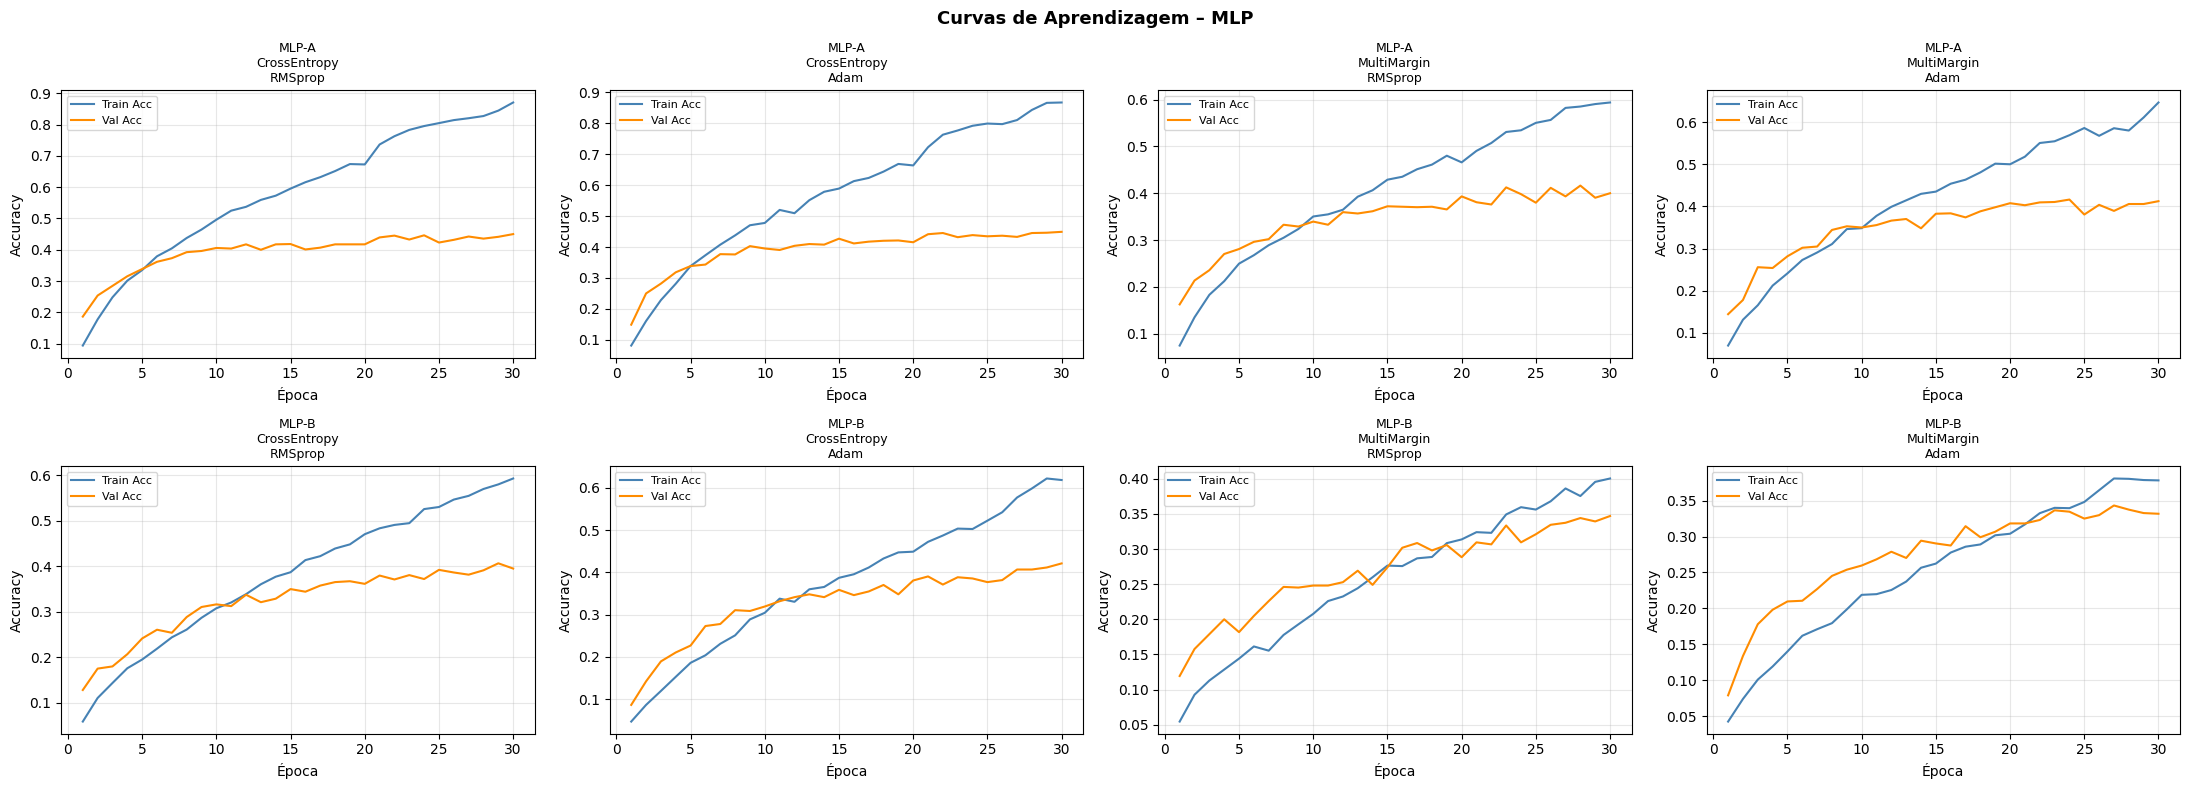

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(22, 8))
axes = axes.flatten()

for ax, (key, r) in zip(axes, results.items()):
    h = r['history']
    epochs = range(1, len(h['train_acc']) + 1)
    ax.plot(epochs, h['train_acc'], label='Train Acc', color='steelblue')
    ax.plot(epochs, h['val_acc'],   label='Val Acc',   color='darkorange')
    ax.set_title(key.replace('_', '\n'), fontsize=9)
    ax.set_xlabel('Época')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Curvas de Aprendizagem – MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

*CONCLUSÕES:* A curva de validação (laranja) chega aos ~45% muito cedo (por volta da época 10-12) e nunca mais sai daí.

O facto de a curva de treino (azul) continuar a subir (chegando perto dos 70-80%) enquanto a de validação fica presa nos 45% confirma que o MLP não tem "inteligência" espacial suficiente para generalizar melhor. Ele aprende o que é uma borboleta no treino, mas não consegue aplicar esse conhecimento a novas fotos.

### 6.2 Curvas de loss

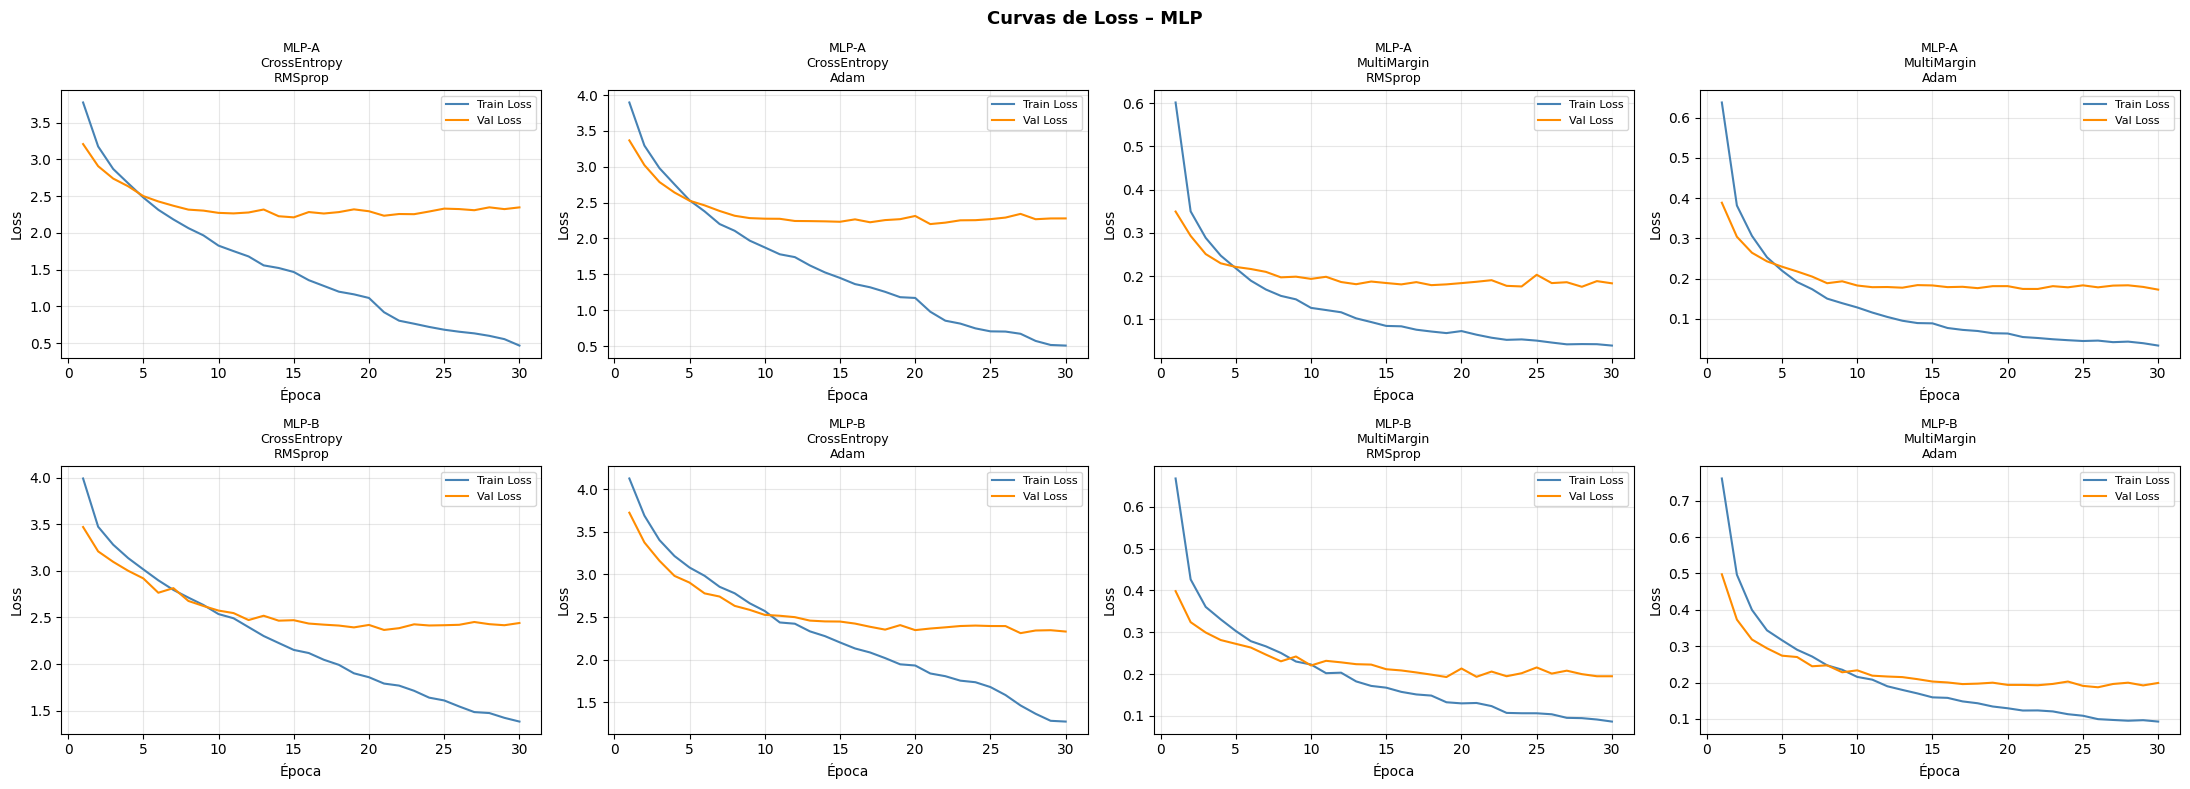

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(22, 8))
axes = axes.flatten()

for ax, (key, r) in zip(axes, results.items()):
    h = r['history']
    epochs = range(1, len(h['train_loss']) + 1)
    ax.plot(epochs, h['train_loss'], label='Train Loss', color='steelblue')
    ax.plot(epochs, h['val_loss'],   label='Val Loss',   color='darkorange')
    ax.set_title(key.replace('_', '\n'), fontsize=9)
    ax.set_xlabel('Época')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Curvas de Loss – MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

*CONCLUSÕES:*
Em alguns dos graficos, a curva azul (Treino) desce vertiginosamente até à epoch 10 e depois estabiliza.

A partir da época 15, a curva laranja (Validação) para de descer e começa a "tremer" ou até a subir ligeiramente no final.

Isto é o sinal de overfitting. O modelo começou a tentar "decorar" ruídos das imagens de treino que não existem nas imagens de validação. 

### 6.3 Comparação em barra

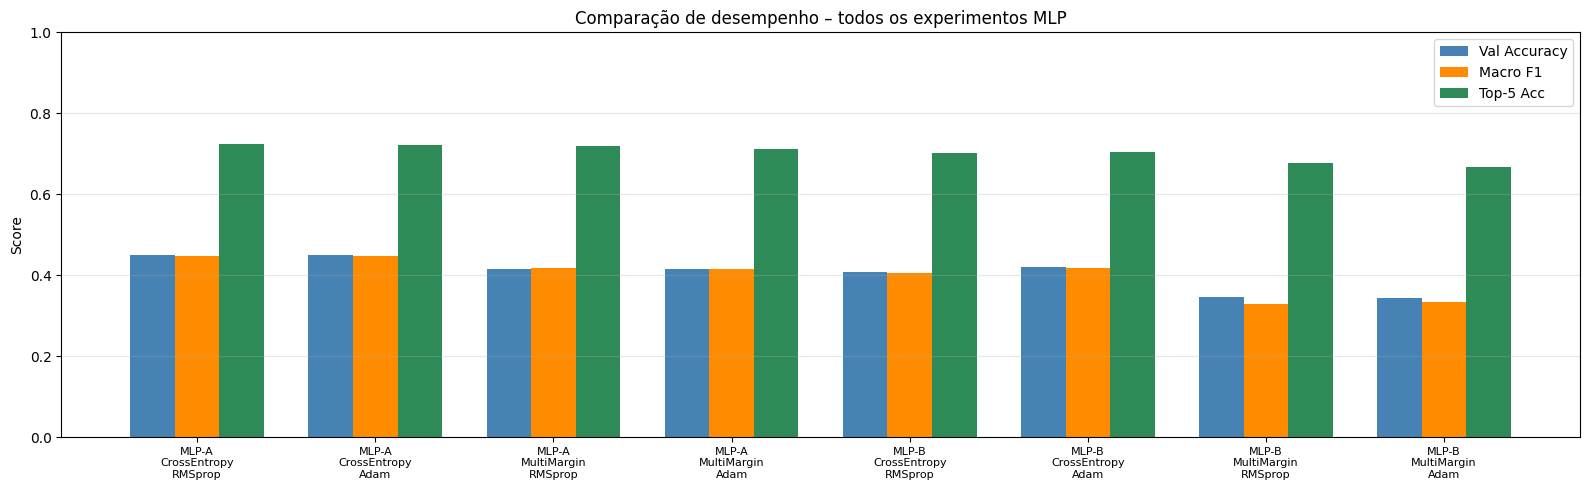

In [12]:
keys   = list(results.keys())
accs   = [results[k]['val_acc']  for k in keys]
f1s    = [results[k]['val_f1']   for k in keys]
top5s  = [results[k]['val_top5'] for k in keys]

x = np.arange(len(keys))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - width, accs,  width, label='Val Accuracy', color='steelblue')
ax.bar(x,         f1s,   width, label='Macro F1',     color='darkorange')
ax.bar(x + width, top5s, width, label='Top-5 Acc',    color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels([k.replace('_', '\n') for k in keys], fontsize=8)
ax.set_ylabel('Score')
ax.set_title('Comparação de desempenho – todos os experimentos MLP')
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4 Confusion Matrix – melhor modelo

Melhor experimento: MLP-A_CrossEntropy_RMSprop  |  Val Acc = 0.4500


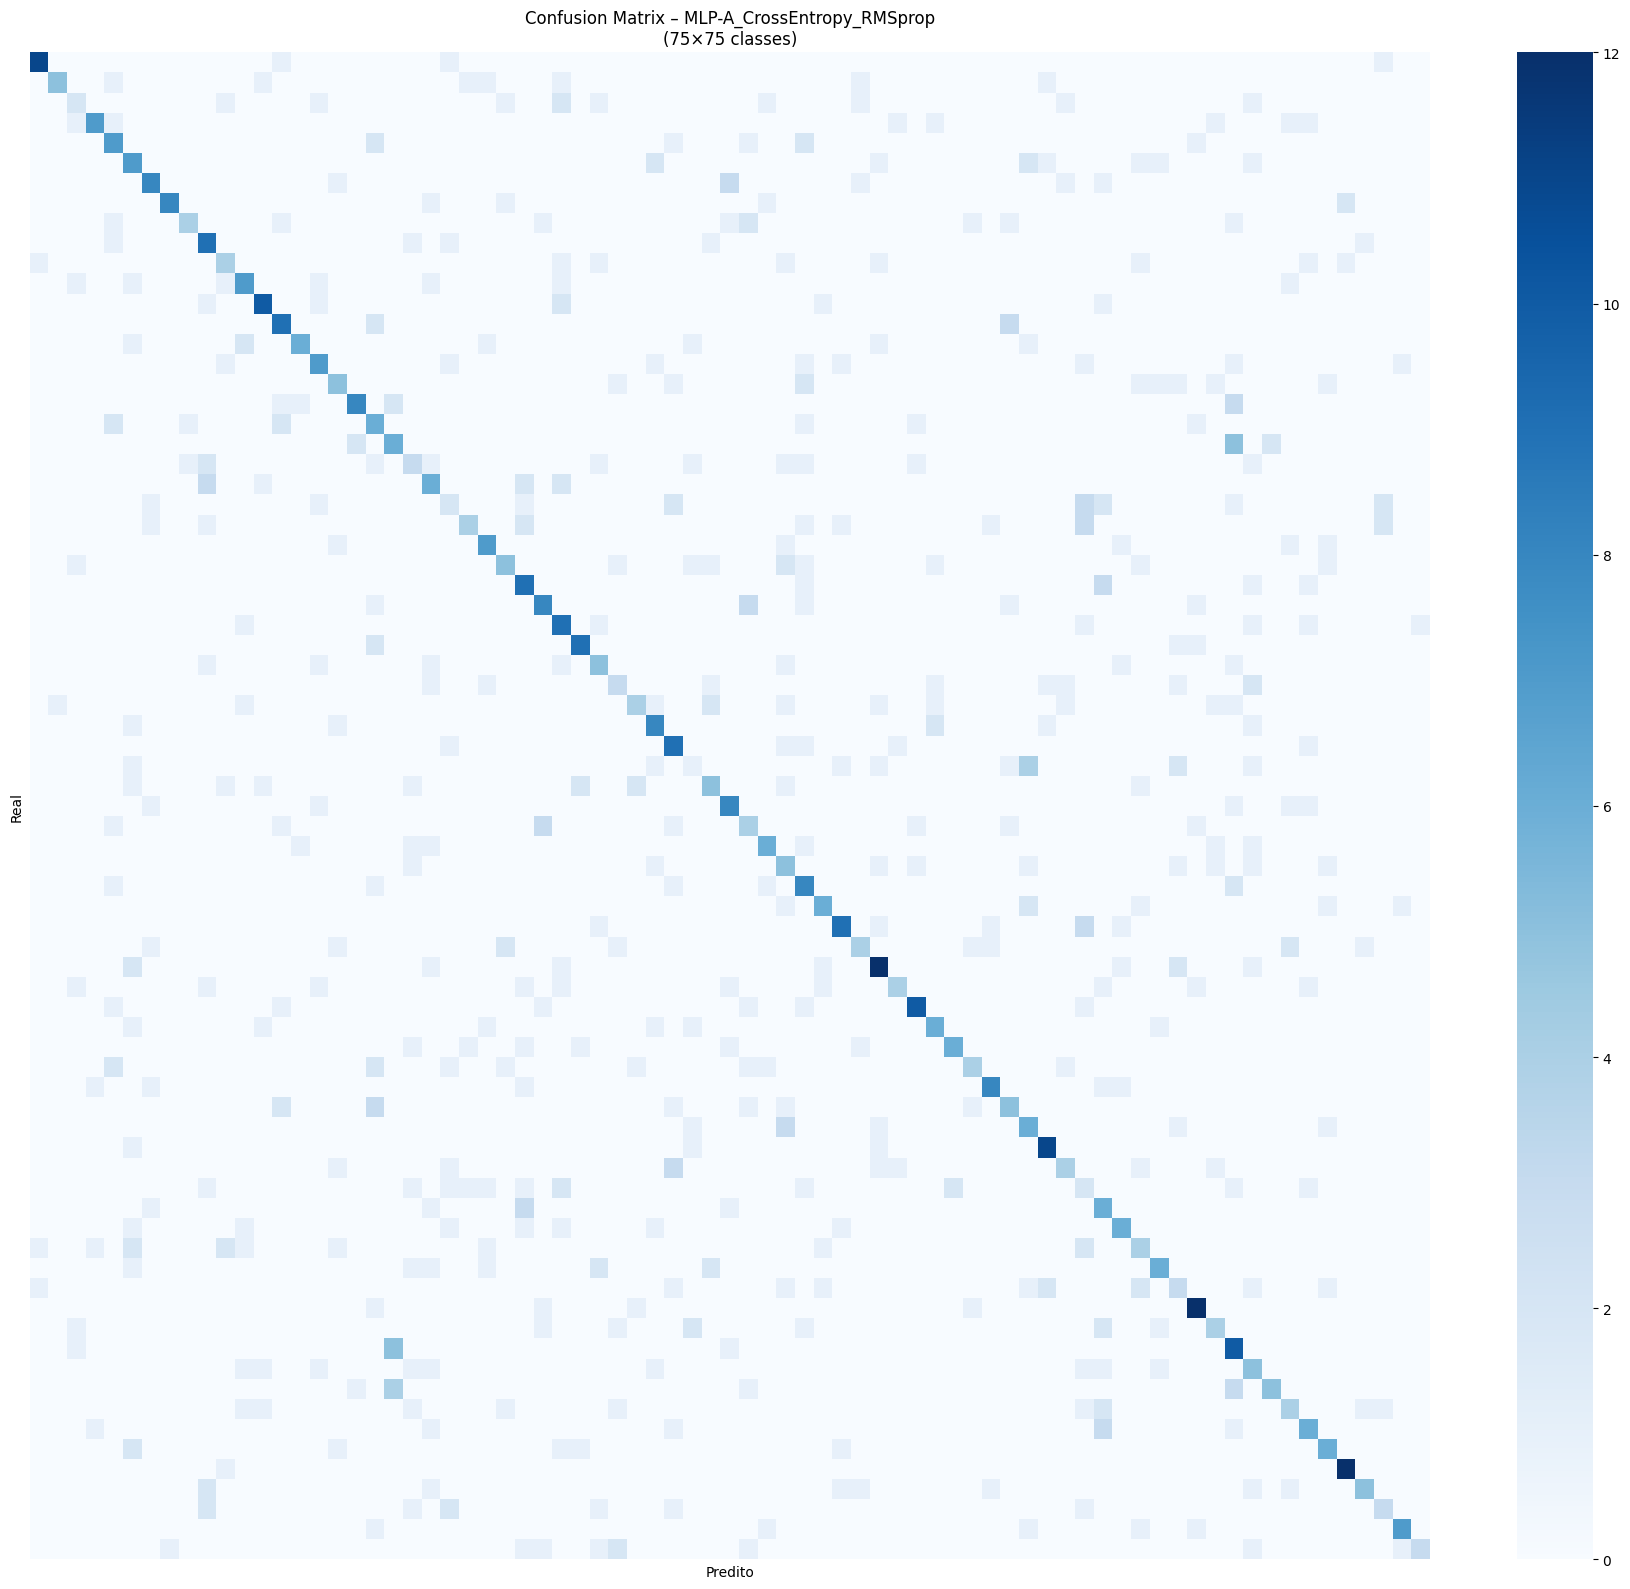

In [13]:
# Selecciona o experimento com maior val_acc
best_key = max(results, key=lambda k: results[k]['val_acc'])
print(f'Melhor experimento: {best_key}  |  Val Acc = {results[best_key]["val_acc"]:.4f}')

preds  = results[best_key]['preds']
labels = results[best_key]['labels']
cm     = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm, ax=ax, cmap='Blues', xticklabels=False, yticklabels=False)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title(f'Confusion Matrix – {best_key}\n(75×75 classes)')
plt.tight_layout()
plt.show()

### 6.5 Classification Report – melhor modelo

In [14]:
print(classification_report(
    labels, preds,
    target_names=classes,
    zero_division=0
))

                           precision    recall  f1-score   support

                   ADONIS       0.79      0.79      0.79        14
AFRICAN GIANT SWALLOWTAIL       0.83      0.42      0.56        12
           AMERICAN SNOOT       0.25      0.17      0.20        12
                    AN 88       0.70      0.50      0.58        14
                  APPOLLO       0.39      0.50      0.44        14
                    ATALA       0.32      0.44      0.37        16
 BANDED ORANGE HELICONIAN       0.57      0.53      0.55        15
           BANDED PEACOCK       0.89      0.62      0.73        13
            BECKERS WHITE       0.67      0.31      0.42        13
         BLACK HAIRSTREAK       0.39      0.64      0.49        14
              BLUE MORPHO       0.36      0.33      0.35        12
        BLUE SPOTTED CROW       0.47      0.50      0.48        14
           BROWN SIPROETA       0.62      0.62      0.62        16
            CABBAGE WHITE       0.50      0.64      0.56     

## 7. Guardar Resultados

Guardamos os resultados dos experimentos em CSV para leitura no notebook `05_results.ipynb`.

In [15]:
import os
import pandas as pd

# Criar directório de resultados se não existir
os.makedirs('../results', exist_ok=True)

# Construir DataFrame com todos os resultados dos experimentos
rows = []
for key, r in results.items():
    rows.append({
        'Model':        'MLP',
        'Experiment':   key,
        'Val Accuracy': round(r['val_acc'],  4),
        'Macro F1':     round(r['val_f1'],   4),
        'Top-5 Acc':    round(r['val_top5'], 4),
    })

df_mlp = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False)

# Guardar CSV
df_mlp.to_csv('../results/mlp_results.csv', index=False)
print('Resultados guardados em ../results/mlp_results.csv')
df_mlp

Resultados guardados em ../results/mlp_results.csv


,Model,Experiment,Val Accuracy,Macro F1,Top-5 Acc
0,MLP,MLP-A_CrossEntropy_RMSprop,0.4500,0.4485,0.7231
1,MLP,MLP-A_CrossEntropy_Adam,0.4490,0.4481,0.7221
5,MLP,MLP-B_CrossEntropy_Adam,0.4212,0.4188,0.7048
2,MLP,MLP-A_MultiMargin_RMSprop,0.4163,0.4179,0.7183
3,MLP,MLP-A_MultiMargin_Adam,0.4163,0.4161,0.7106
4,MLP,MLP-B_CrossEntropy_RMSprop,0.4067,0.4050,0.7029
6,MLP,MLP-B_MultiMargin_RMSprop,0.3471,0.3291,0.6769
7,MLP,MLP-B_MultiMargin_Adam,0.3433,0.3347,0.6663


## 8. Análise e Conclusões

### Um MLP para classificação de imagens
Um MLP **flatten** a imagem antes de a processar, perdendo toda a estrutura espacial 2D. Isto é uma desvantagem importante para imagens naturais, onde padrões locais (texturas, bordas, padrões de asa) são informativos. As CNNs e ResNets exploram precisamente essa estrutura.

### Comparação de losses
- **CrossEntropyLoss**: softmax implícito; penaliza a probabilidade da classe correta de forma contínua; indicada para classificação multi-classe com rótulos duros.
- **MultiMarginLoss**: loss de margem hinge multi-classe; maximiza a margem entre a classe correcta e as outras; tende a ser mais esparsa (zero loss quando a margem já é satisfeita).

### Comparação de optimizadores
- **RMSprop**: adapta o learning rate por parâmetro com base na média das magnitudes recentes dos gradientes; bom para redes recorrentes e problemas não-estacionários.
- **Adam**: combina momento com RMSprop; mais popular em visão; tende a convergir mais rapidamente.

### Limitações do MLP neste problema
- Perde informação espacial (necessária para reconhecimento de espécies)
- Grande número de parâmetros com input de alta dimensão
- Sujeito a overfitting rápido sem regularização adequada
